## Data augmentation at test time
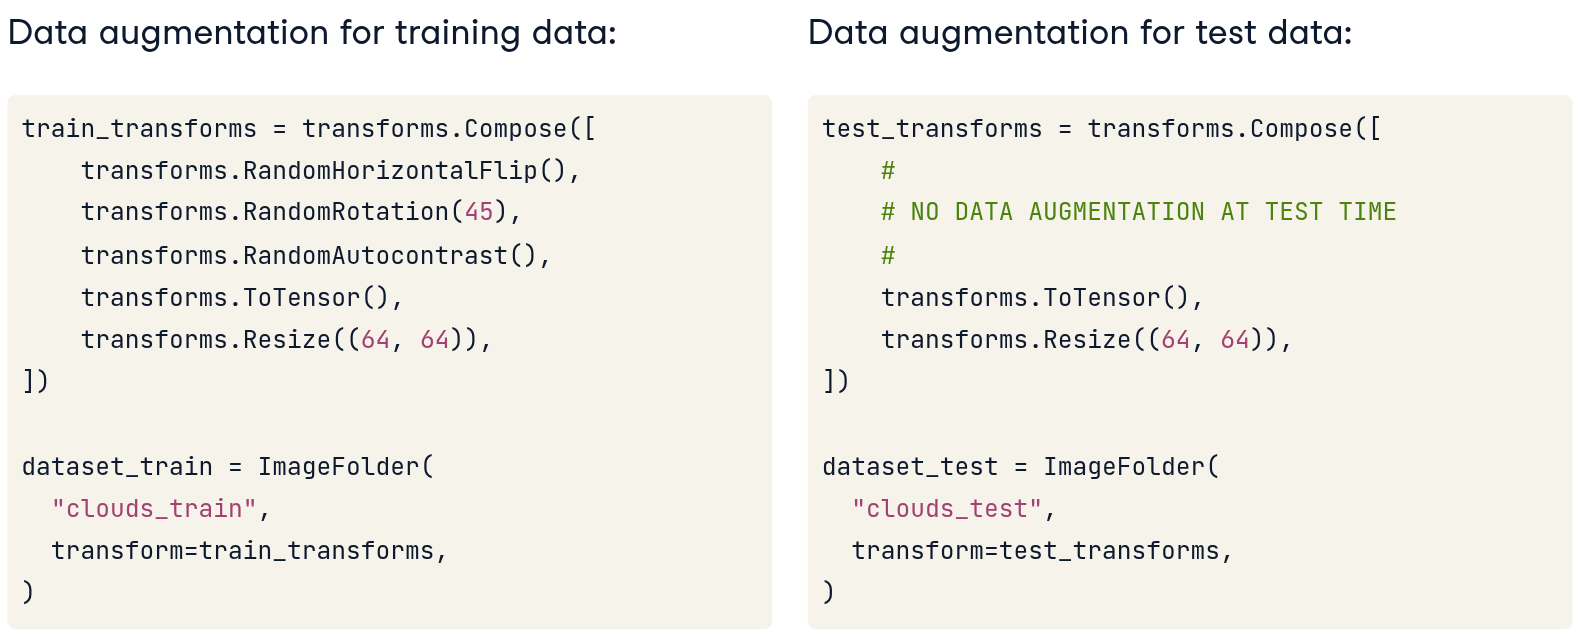

## Precision & Recall: binary classification
In binary classification:
- Precision: Fraction of positive predictions
- Recall: Fraction of all positive examples correctly predicted
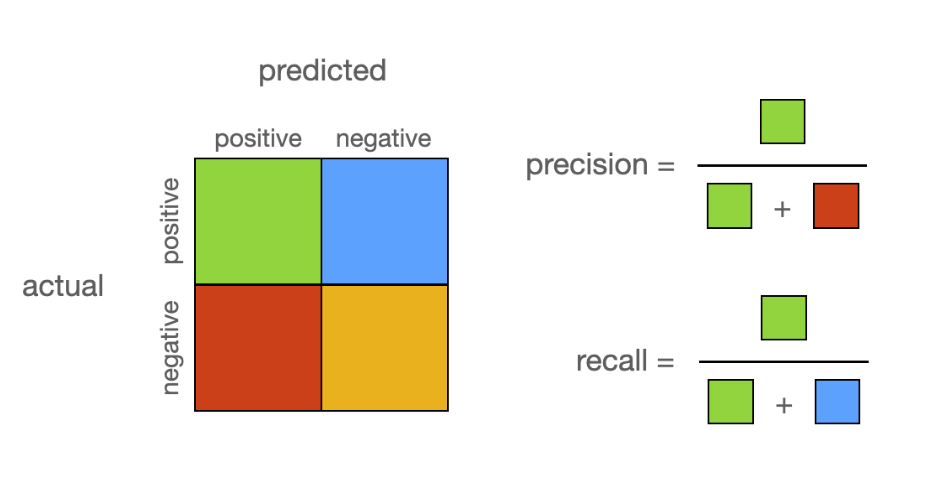

In multi-class classification: separate precision and recall for each class
- Precision: Fraction of cumulus-predictions that were correct
- Recall: Fraction of all cumulus examples correctly predicted

## Averaging mult-class metrics
- With 7 classes, we have 7 precision and 7 recall scores
- We can analyze them per-class, or aggregate:
    - **Micro average**:global calculation
    - **Macro average**:mean of per-class metrics
    - **Weighted average**:weighted average of per-class metrics

In [ ]:
from tracemalloc import take_snapshot

import torch
from torchmetrics import Recall

recall_per_class = Recall(task='multiclass', num_classes=7, average=None)
recall_micro = Recall(task='multiclass', num_classes=7, average='micro')
recall_macro = Recall(task='multiclass', num_classes=7, average='macro')
recall_weighted = Recall(task='multiclass', num_classes=7, average='weighted')

When to use each:
- Micro: Imbalanced datasets
- Macro: Care about performance on small classes
- Weighted:Consider errors in larger classes as more import

## Evaluation loop
- Import and define precision and recall metrics
- Iterate over test examples with no gradient
- For each test batch, get model outputs, take most likely class, and pass it to metric functions along with the labels
- Compute the metrics

In [ ]:
from torchmetrics import Precision, Recall

metric_precision = Precision(
    task='multiclass', num_classes=7, average='macro'
)
metric_recall = Recall(
    task='multiclass', num_classes=7, average='macro'
)

net.eval()
with torch.no_grad():
    for images, labels in dataloader_test:
        outputs = net(images)
        _, preds = torch.max(outputs, 1)
        metric_precision(preds, labels)
        metric_recall(preds, labels)

precision = metric_precision.compute()
recall = metric_recall.compute()

In [ ]:
print(f'Precision: {precision}')
print(f'Recall: {recall}')

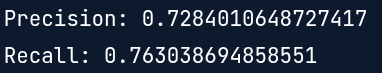

## Analyzing performance per class
- Compute metric with ```average=None```
- This gives one score per class
- ```Dataset```'s ```.class_to_idx``` attribute maps class names to indices

In [ ]:
metric_recall = Recall(
    task='multiclass', num_classes=7, average=None
)
net.eval()
with torch.no_grad():
    for images, labels in dataloader_test:
        outputs = net(images)
        _, preds = torch.max(outputs, 1)
        metric_recall(preds, labels)
recall = metric_recall.compute()
print(recall)

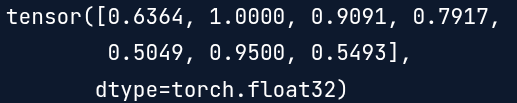

In [ ]:
dataset_test.class_to_idx

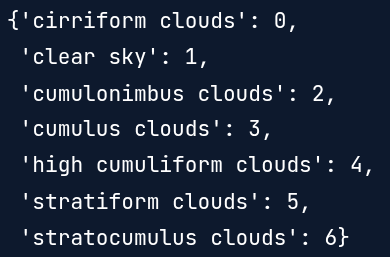

Use dictionary comprehensionm
- k = class name, e.g. cirriform clouds
- v = class index, e.g. 0
- recall[v] = tensor(0.6364, dtype=torch.float32)
- recall[v].item() = 0.6364

In [ ]:
{
    k: recall[v].item()
    for k, v in dataset_test.class_to_idx.items()
}

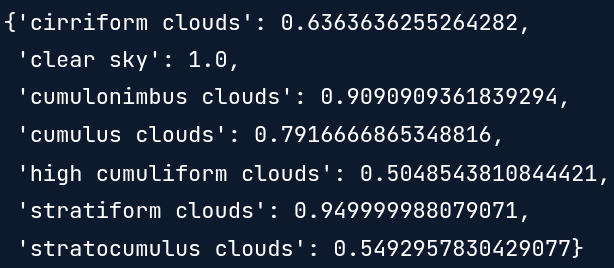